# Task 2 - Ternary Classification Model : Data analysis and Pre processing investigation

### Motivation 

As the FLAME dataset was shot over a forest, lakes are a common occurance in the video. The number of lakes heavily pads the No Fire data set resulting the previosuly seen pattern of No fire images being recorded as Fire images. Creating a Ternary Fire, No Fire and Lake would result in a potentially more accurate and balanced model as each class would be more accurately split and defined.

### Main focuses of this Notebook

This notebook considers the format which th dataset was presented more thouroughly as this problem presents no test dataset. As a result a lot of attention has to be paid to how exactly the validation and test split would be handled as this would especially be liable to data leakage. This notebook mainly is an extention of the binary data notebook, extending it to how would various image processing steps handle major imbalances in classes.

### Steps followed

* Single dataset file is split, image hashing and various tools are used to evaluate the success of this
* Data leakage and over fitting is evaluated and nessaccery steps are discussed
* Class imbalance is evaluated and various ways of handling it are tested

### Summary 

The goal of this notebook is to find a way to maintain the most amount of useful data possible while preventing significant data leakage and major class bias.

In [ ]:
# importing necassary libraries

import numpy as np
import sklearn
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import imageio.v3 as iio
import os
from PIL import Image
import imagehash
import shutil
from sklearn.model_selection import train_test_split

import pandas as pd
from collections import Counter
import random
import seaborn as sns


# image size, batch size and random seed for reproducibility
Image_size = 96
Batch = 32
Random_seed = 42

### Data splitting and exploration

Like Binary data notebook, image sizes are resized to 96 x 96 for accuracy and speed. Frame repition is also the same with the difference of there being no Test data file. This means a test split of the training folder is needed.

Analysing the dataset, it is evident that lakes significantly outnumber No Fire images, nearly 3 to 1. This would therefore  cause majority class bias, making Lake predictions highly favourable. All predictions would be Fire or Lakes with none going to No Fire. Below is a copy of the predefined augmentation and class weight functions.


In [ ]:
def apply_blur(img):
    ''' Apply a simple average blur to the input image to simulate 
        motion blur or out of focus blur.'''

    img = tf.expand_dims(img, 0)
    img = tf.nn.avg_pool2d(img, ksize=3, strides=1, padding='SAME')
    return tf.squeeze(img, 0)

def augment(image, label):
    ''' Apply random augmentations to the input image to increase the 
    diversity of the training data and improve model robustness.'''

    # normalize to [0,1] and apply random flips, rotations, brightness/contrast/saturation/hue adjustments
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform((), 0, 4, dtype=tf.int32))
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.6)
    image = tf.image.random_hue(image, max_delta=0.05)
    
    # add random haze effect by blending the image with a light gray haze
    haze_intensity = tf.random.uniform((), 0.05, 0.25)
    haze = tf.ones_like(image) * 0.7

    # randomly apply the haze effect to some images to simulate different weather conditions
    image = tf.cond(
        tf.random.uniform(()) > 0.5,
        lambda: image * (1 - haze_intensity) + haze * haze_intensity,
        lambda: image
    )

    # randomly apply a blur effect to some images to simulate motion blur or out of focus blur
    image = tf.cond(
        tf.random.uniform(()) > 0.6,
        lambda: apply_blur(image),
        lambda: image
    )

    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label


def compute_class_weights_Tri(ds):
    '''Compute class weights for imbalanced datasets.
    '''
    # extract labels from the dataset
    labels = np.concatenate([y.numpy() for _, y in ds.batch(512)])    
    classes = np.unique(labels)
    # compute class weights using sklearn's compute_class_weight function
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels)
    class_weights = dict(zip(classes, weights))
    print(f"Class weights: {class_weights}")
    return class_weights


def normalize(image, label):
    ''' Normalize the input image to [0,1] range for better training stability.'''
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def load_and_preprocess(path, label):
    ''' Load the image from the given path and preprocess it by resizing to the target size.'''
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [Image_size, Image_size])
    return img, label


Before the class bias can be tackled the data first has to be split. My first trails involved simply splitting the dataset with no hashing or accounting for data leakage. I will demonstrate that and then a refined way which first hashes images, then splits them and checks for data leakage.

In [ ]:
# training data split for the ternary classifier with 70% training, 15% validation and 15% test data
train_Tri_raw = tf.keras.utils.image_dataset_from_directory(
    "Training_Tri/",
    validation_split=0.30,
    subset="training",
    seed=Random_seed, 
    image_size=(Image_size, Image_size),
    batch_size=None,
    shuffle=True  
)

# create a temporary dataset for validation and test split
temp_ds = tf.keras.utils.image_dataset_from_directory(
    "Training_Tri/",
    validation_split=0.30,
    subset="validation",
    seed=Random_seed,
    image_size=(Image_size, Image_size),
    batch_size=None,
    shuffle=True  
)

# split the temporary dataset into validation and test datasets (15% each)
val_size = int(0.5 * len(temp_ds))
val_Tri_raw = temp_ds.take(val_size)
test_Tri_raw = temp_ds.skip(val_size)


# final datasets with augmentation and normalisition applied
train_ds = (
    train_Tri_raw
    .cache() 
    .shuffle(5000, seed=Random_seed)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_Tri_raw
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    test_Tri_raw
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)

def check_leakage_by_class(tr_p, tr_l, te_p, te_l):
    ''' Check for data leakage by comparing perceptual 
    hashes of training and test images within each class.'''

    train_hashes = {}
    for p, l in zip(tr_p, tr_l):
        # find hash of the training images
        with Image.open(p) as img:
            h = str(imagehash.phash(img))
            train_hashes[h] = l

    for cls in np.unique(te_l):
        # find all test images of the current class
        cls_paths = [p for p, l in zip(te_p, te_l) if l == cls]
        leak = 0
        for p in cls_paths:
            with Image.open(p) as img:
                h = str(imagehash.phash(img))
                if h in train_hashes:
                    leak += 1
        # print the leakage percentage for the current class
        print(f"Class {cls}: {leak}/{len(cls_paths)} leaked ({100*leak/len(cls_paths):.1f}%)")

check_leakage_by_class(train_p, train_l, test_p, test_l)


Found 39375 files belonging to 3 classes.
Using 27563 files for training.
Found 39375 files belonging to 3 classes.
Using 11812 files for validation.
Class 0: 0/243 leaked (0.0%)
Class 1: 0/243 leaked (0.0%)
Class 2: 0/243 leaked (0.0%)


The dataset is clearly highly unbalanced and suffers from data leakage, significantly impacts model performance. A baseline model is used for comparison to show how the model behaves without any data engineering, highlighting its tendency to favour dominant classes, further enforced by sever data leakage. This demonstrates that the model struggles to learn minority classes in the ternary task without the use of techniques such as data augmentation or class weighting.

The model below is a large convolution neural network, based of previous renditions of the binary classifier, using dropout and pooling layers. However now the final layer has 3 nodes given the 3 outcomes the data could have.

In [ ]:
# CNN model architecture with convolutional layers, batch normalization, dropout and global average pooling.
model = keras.models.Sequential([
    
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
    
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
   
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.3),
   
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.GlobalAveragePooling2D(),
    
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(3, activation='softmax') 
])

# compile the model with Adam optimizer, sparse categorical crossentropy loss 
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# fitting model
history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    class_weight=compute_class_weights_Tri(train_ds.unbatch())
)

Class weights: {0: 0.5262122947689958, 1: 1.1026964314290286, 2: 5.187841144362883}
Epoch 1/30
862/862 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.8703 - loss: 0.0352 - val_accuracy: 0.6996 - val_loss: 0.0591 - learning_rate: 1.0000e-04
Epoch 2/30
862/862 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9310 - loss: 0.0192 - val_accuracy: 0.8080 - val_loss: 0.0603 - learning_rate: 1.0000e-04
Epoch 3/30
862/862 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9401 - loss: 0.0155 - val_accuracy: 0.9170 - val_loss: 0.0185 - learning_rate: 1.0000e-04
Epoch 4/30
862/862 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9468 - loss: 0.0132 - val_accuracy: 0.9538 - val_loss: 0.0107 - learning_rate: 1.0000e-04
Epoch 5/30
862/862 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9531 - loss: 0.0115 - val_accuracy: 0.9646 - val_loss: 0.0085 - learning_rate: 1.0000e-04
Epoch 6/30
862/862 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9553 - loss: 0.0103 - val_accuracy: 0.9636 - val_loss: 0.0

In [ ]:
true_labels = []
y_pred_prob = []

# iterate through test dataset batches and collect predictions and true labels
for images, labels in test_ds:
    preds = model(images, training=False)
    true_labels.extend(labels.numpy())
    y_pred_prob.extend(preds.numpy())

# convert to numpy arrays and extract predicted classes from probability distributions
true_labels = np.array(true_labels)
y_pred_prob = np.array(y_pred_prob)
pred_classes = np.argmax(y_pred_prob, axis=1)

# evaluate the model on the test dataset and print the loss, accuracy, confusion matrix and classification report
loss, acc = model.evaluate(test_ds)
print(f"Test Loss:      {loss:.4f}")
print(f"Test Accuracy:  {acc:.4f}")
cm = confusion_matrix(true_labels, pred_classes)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    true_labels,
    pred_classes,
    target_names=train_Tri_raw.class_names
    ))

185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9695 - loss: 0.0078
Test Loss:      0.0078
Test Accuracy:  0.9695

Confusion Matrix:
[[3721    0   38]
 [   0 1765    0]
 [ 136    6  240]]

Classification Report:
              precision    recall  f1-score   support

        Fire       0.96      0.99      0.98      3759
        Lake       1.00      1.00      1.00      1765
     No_Fire       0.86      0.63      0.73       382

    accuracy                           0.97      5906
   macro avg       0.94      0.87      0.90      5906
weighted avg       0.97      0.97      0.97      5906



The data leakage is clearly taking affect. The model is nearly 100% accurate, meaning that data from the training data split into the validation and test data. Clearly alot of attention has to paid to not let this happen.

### Image Hashing and data splitting

To avoid this problem, the whole data set will be hashed. Then the data will be split into seperate newly made folders 'Ternary_Test', 'Ternary_Training' and 'Ternary_Validation'. 

In [ ]:
def remove_duplicates_smart(paths, labels, class_to_idx):
    ''' Remove duplicate images based on perceptual hashing to ensure data quality and prevent overfitting.'''

    unique_hashes = {}
    clean_paths, clean_labels = [], []
    no_fire_idx = class_to_idx.get('No_Fire', 2) 
    
    print(f"Checking {len(paths)} files for duplicates...")
    # iterate through images and keep only unique ones based on their perceptual hash
    for p, l in zip(paths, labels):
        try:
            with Image.open(p) as img:
                h = str(imagehash.phash(img, hash_size=8))
                if h not in unique_hashes:
                    unique_hashes[h] = p
                    clean_paths.append(p)
                    clean_labels.append(l)
        except:
            continue
    return clean_paths, clean_labels

# sorting class names and creating a mapping from class names to indices
base_dir = "Training_Tri/"
class_names = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
class_to_idx = {name: i for i, name in enumerate(class_names)}

all_p, all_l = [], []

# iterate through each class directory and collect all image paths and their corresponding labels

for class_name in class_names:
    c_path = os.path.join(base_dir, class_name)
    files = [os.path.join(c_path, f) for f in os.listdir(c_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_p.extend(files)
    all_l.extend([class_to_idx[class_name]] * len(files))


# cleaning duplicated data sets and splitting 
clean_p, clean_l = remove_duplicates_smart(all_p, all_l, class_to_idx)
train_val_p, test_p, train_val_l, test_l = train_test_split(
    clean_p, clean_l, test_size=0.2, random_state=42, stratify=clean_l
)
train_p, val_p, train_l, val_l = train_test_split(
    train_val_p, train_val_l, test_size=0.15, random_state=42, stratify=train_val_l
)

# moving data to folders for the ternary classifier
def move_to_folders(paths, labels, root_folder):
    for p, l in zip(paths, labels):
        dest_dir = os.path.join(root_folder, class_names[l])
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy2(p, os.path.join(dest_dir, os.path.basename(p)))

# checking leakage again
check_leakage_by_class(train_p, train_l, test_p, test_l)

# printing final counts and where folders are moved to
print("Moving files to Ternary folders...")
move_to_folders(train_p, train_l, "Ternary_Training")
move_to_folders(test_p, test_l, "Ternary_Test")
move_to_folders(val_p, val_l, "Ternary_Validation")

print(f"Done! Final counts -> Train: {len(train_p)}, Val: {len(val_p)}, Test: {len(test_p)}")

Checking 39375 files for duplicates...
Moving files to Ternary folders...
Done! Final counts -> Train: 6154, Val: 1086, Test: 1810


Now that new files are created, Data processing can take place without worrying for data leakage. Like the previous notebooks I will compare downsampling and hashing with weights and hashing and evaluate the effects. As the class weights for Fire, Lakes and No Fires are 0.7,1,3 repectively my intital prediciton is that the weighted test will be significantly biased compared to the downsampling example as such heavy imbalances cant be overcomed with big weights.

In [ ]:
# counts of each class in the training set before balancing
counts = Counter(train_l)
print(f"Before balancing: {dict(counts)}")

min_count = min(counts.values())
print(f"Limiting each class to: {min_count} samples")

# making copies of the original training and validation paths and labels before balancing
train_p_orig, train_l_orig = list(train_p), list(train_l)
val_p_orig, val_l_orig = list(val_p), list(val_l)


print(f"Captured 'Original' Hashed Counts -> Train: {Counter(train_l_orig)}")

def balance_split(paths, labels, seed=Random_seed):
    ''' Balance the dataset by limiting each class to the same 
    number of samples as the least represented class.'''

    # count the number of samples in each class and find the minimum count
    counts = Counter(labels)
    min_count = min(counts.values())
    combined = list(zip(paths, labels))
    random.seed(seed)
    random.shuffle(combined)
    bal_p, bal_l = [], []
    class_seen = Counter()

    for p, l in combined:
        # only keep samples from each class until we reach the minimum count for that class
        if class_seen[l] < min_count:
            bal_p.append(p)
            bal_l.append(l)
            class_seen[l] += 1
    return bal_p, bal_l


# balancing the training, validation and test sets to have the same number of samples for each class
train_p, train_l = balance_split(train_p, train_l)
val_p,   val_l   = balance_split(val_p,   val_l)
test_p,  test_l  = balance_split(test_p,  test_l)

print(f"Train: {Counter(train_l)}")
print(f"Val:   {Counter(val_l)}")
print(f"Test:  {Counter(test_l)}")


Class 0: 0/1032 leaked (0.0%)
Class 1: 0/535 leaked (0.0%)
Class 2: 0/243 leaked (0.0%)
Before balancing: {0: 3506, 1: 1821, 2: 827}
Limiting each class to: 827 samples
Captured 'Original' Hashed Counts -> Train: Counter({0: 3506, 1: 1821, 2: 827})
Train: Counter({1: 827, 2: 827, 0: 827})
Val:   Counter({1: 146, 0: 146, 2: 146})
Test:  Counter({2: 243, 0: 243, 1: 243})


The file sizes significantly drops due to how few files are in the No Fire dataset. Below defines the code to split and run the experimeents regarding weights vs downsampling. notice the computed class weights are 1 for the below data as this set was downsampled.

In [ ]:
# final datasets with augmentation and normalisition applied
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_p, train_l)) 
    .shuffle(len(train_p), seed=Random_seed)
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_p, val_l))
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_p, test_l)) 
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

# class weights for the balanced dataset
train_raw_for_weights = (
    tf.data.Dataset.from_tensor_slices((train_p, train_l))
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
)

class_weights = compute_class_weights_Tri(train_raw_for_weights)

Class weights: {0: 1.0, 1: 1.0, 2: 1.0}



--- Running Experiment: Hashed + Weighted ---
Class weights: {0: 0.5850922228560563, 1: 1.1264872780523523, 2: 2.4804514308746475}
Results for Hashed + Weighted:
              precision    recall  f1-score   support

        Fire       0.50      1.00      0.67       243
        Lake       0.99      1.00      0.99       243
     No_Fire       0.00      0.00      0.00       243

    accuracy                           0.67       729
   macro avg       0.50      0.67      0.55       729
weighted avg       0.50      0.67      0.55       729


--- Running Experiment: Hashed + Downsampled ---


C:\Users\jaadt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jaadt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jaadt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_clas

Results for Hashed + Downsampled:
              precision    recall  f1-score   support

        Fire       0.62      0.64      0.63       243
        Lake       0.98      1.00      0.99       243
     No_Fire       0.62      0.58      0.60       243

    accuracy                           0.74       729
   macro avg       0.74      0.74      0.74       729
weighted avg       0.74      0.74      0.74       729



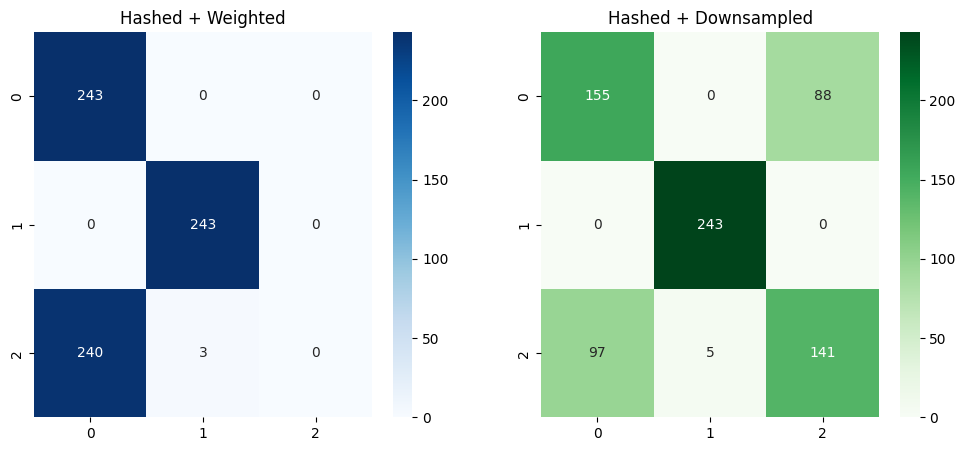

In [ ]:
def run_experiment(train_p, train_l, val_p, val_l, test_p, test_l, experiment_name, use_weights=False):
    ''' Run a training and evaluation experiment with the given datasets and settings.'''

    print(f"\n--- Running Experiment: {experiment_name} ---")
    
    # helper function that applys preprocessing and augmentation to the datasets based on whether it's training or not
    def prepare_ds(p, l, is_training=False):
        # applying the same preprocessing and augmentation steps as before to create the datasets for training, validation and testing
        ds = tf.data.Dataset.from_tensor_slices((p, l))
        ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        if is_training:
            ds = ds.shuffle(len(p)).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
        else:
            ds = ds.map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
        return ds.batch(Batch).prefetch(tf.data.AUTOTUNE)

    # prepare the datasets for the current experiment
    curr_train_ds = prepare_ds(train_p, train_l, is_training=True)
    curr_val_ds = prepare_ds(val_p, val_l)
    curr_test_ds = prepare_ds(test_p, test_l)

    # simple CNN model architecture for the experiments
    model = keras.models.Sequential([
        keras.layers.Input(shape=(Image_size, Image_size, 3)),
        keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
        keras.layers.MaxPooling2D(),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(3, activation='softmax')
    ])

    # compiling the model
    model.compile(optimizer=keras.optimizers.Adam(1e-4), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])

    # compute class weights if needed for the current experiment
    weights = None
    if use_weights:
        weights = compute_class_weights_Tri(tf.data.Dataset.from_tensor_slices((train_p, train_l)).map(load_and_preprocess))

    model.fit(curr_train_ds, validation_data=curr_val_ds, epochs=15, 
              class_weight=weights, verbose=0)

    # evaluting model and outputting confusion matrix and classification report
    y_true, y_pred = [], []
    for imgs, lbls in curr_test_ds:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(lbls.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    print(f"Results for {experiment_name}:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    return confusion_matrix(y_true, y_pred)


# running experiment on hashed data thats been downsampled or weighted
cm_unbalanced = run_experiment(train_p_orig, train_l_orig, val_p_orig, val_l_orig, 
                               test_p, test_l, "Hashed + Weighted", use_weights=True)

cm_balanced = run_experiment(train_p, train_l, val_p, val_l, 
                             test_p, test_l, "Hashed + Downsampled", use_weights=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# plotting confusion matrices for both experiments side by side for comparison
sns.heatmap(cm_unbalanced, annot=True, fmt='d', ax=ax[0], cmap='Blues').set_title('Hashed + Weighted')
sns.heatmap(cm_balanced, annot=True, fmt='d', ax=ax[1], cmap='Greens').set_title('Hashed + Downsampled')
plt.show()

While the weighted model performs perfectly on the Fire and Lake classes, It completely fails at the No fire images. As expected the heavily imbalanced classes lead to poorly performing models. While the downsampled model performs worse on the Fire class, It fares much better overall and produces a more reliable model. This shows that the best baseline for machine learning optimisation is to use ImageHashing and downsampling.

### Conclusion

While the data processing in general has had similar steps to the binary classifier, the added complication of having to split testing data from the same folder made data leakage a very serious problem that was mitigated through hashing the folder and spliting the classes immediately after. Analysis also shows that the best way to clean the data is using downsampling. While the basic model used above doesnt predict Fires or lack there of well, further model optmisations will provide a more accurate outcome.